In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split

In [2]:
# ==========================================
# 1. CONFIGURATION
# ==========================================
DATA_DIR = './processed_data' # Ensure this matches where you ran make_dataset.py
TRAIN_FILE = os.path.join(DATA_DIR, 'quickdraw_train.npz')
TEST_FILE = os.path.join(DATA_DIR, 'quickdraw_test.npz')


BATCH_SIZE = 128
EPOCHS = 5
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "mps" if torch.backends.mps.is_available() else "cpu")
print(f"Using device: {DEVICE}")


Using device: mps


In [3]:
# ==========================================
# 2. DATASET CLASS (The NPZ Loader)
# ==========================================

class QuickDrawDataset(Dataset):
    def __init__(self, file_path, mode='train'):
        """
        Args:
            file_path (str): Path to the .npz file
            mode (str): 'train' (loads images & labels) or 'test' (loads images only)
        """
        self.mode = mode

        if not os.path.exists(file_path):
            raise FileNotFoundError(f"Could not find file: {file_path}")

        print(f"Loading {mode} data from {file_path}...")
        data = np.load(file_path)

        if mode == 'train':
            # Load x_train and y_train
            self.x = data['x_train']
            self.y = data['y_train']
            self.classes = data['class_names']
            print(f"Loaded {len(self.x)} training samples. Classes: {len(self.classes)}")

        elif mode == 'test':
            # Load test_images (for leaderboard inference)
            self.x = data['test_images']
            self.y = None
            print(f"Loaded {len(self.x)} test images.")

        # Pre-processing:
        # Convert to Float Tensor and Normalize (0-255 -> 0-1)
        self.x = torch.from_numpy(self.x).float() / 255.0

        if self.y is not None:
            self.y = torch.from_numpy(self.y).long()

    def __len__(self):
        return len(self.x)

    def __getitem__(self, idx):
        img = self.x[idx]
        if self.mode == 'train':
            label = self.y[idx]
            return img, label
        else:
            return img

In [4]:
# ==========================================
# 3. PREPARE DATALOADERS
# ==========================================

CLASSES = ['apple', 'baseballbat', 'basketball', 'clock', 'compass', 'cookie', 'donut', 'ladder', 'mountain', 'pizza', 'rabbit', 'soccerball', 'spider', 't-shirt', 'wheel']

# 1. Load the Training Data
full_train_dataset = QuickDrawDataset(TRAIN_FILE, mode='train')
NUM_CLASSES = len(full_train_dataset.classes)

# 2. Create Validation Split (80% Train / 20% Val)
train_size = int(0.8 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = random_split(full_train_dataset, [train_size, val_size])

# 3. Create Loaders
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(f"Train samples: {len(train_dataset)} | Validation samples: {len(val_dataset)}")

Loading train data from ./processed_data/quickdraw_train.npz...
Loaded 60000 training samples. Classes: 15
Train samples: 48000 | Validation samples: 12000


### Part A: The Pancake (Width Focus) Train a shallow but wide network.

In [86]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================


class The_Pancake(nn.Module):
    def __init__(self, input_size = 784, hidden_size1 = 1500, hidden_size2 = 800 , num_classes = 15):
        super(The_Pancake,self).__init__()

        self.model = nn.Sequential(
        nn.Flatten(),
        
        nn.Linear(input_size, hidden_size1),
        nn.BatchNorm1d(1500),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(hidden_size1, hidden_size2),
        nn.BatchNorm1d(800),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(hidden_size2, num_classes)
        )

    def forward(self, x):
        return self.model(x)





In [87]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = The_Pancake().to(DEVICE)

dummy_input = torch.randn(8, 1, 28, 28).to(DEVICE)  # batch of 8 images
output = model(dummy_input)

print(output.shape)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0007, weight_decay=1e-3)


torch.Size([8, 15])


In [88]:

def train_model(model, train_loader, val_loader, epochs=35):

    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):

        # ===== TRAIN =====
        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_accuracy = 100 * train_correct / train_total
        train_acc_list.append(train_accuracy)

        # ===== VALIDATION =====
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_acc_list.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | "
              f"Train Acc: {train_accuracy:.2f}% | "
              f"Val Acc: {val_accuracy:.2f}%")

    return train_acc_list, val_acc_list

In [89]:
train_acc, val_acc = train_model(model, train_loader, val_loader, epochs=35)

Epoch [1/35] | Train Acc: 64.68% | Val Acc: 70.08%
Epoch [2/35] | Train Acc: 71.72% | Val Acc: 73.49%
Epoch [3/35] | Train Acc: 74.34% | Val Acc: 74.40%
Epoch [4/35] | Train Acc: 75.50% | Val Acc: 75.12%
Epoch [5/35] | Train Acc: 76.65% | Val Acc: 76.34%
Epoch [6/35] | Train Acc: 77.74% | Val Acc: 77.34%
Epoch [7/35] | Train Acc: 78.62% | Val Acc: 77.45%
Epoch [8/35] | Train Acc: 79.34% | Val Acc: 77.53%
Epoch [9/35] | Train Acc: 79.89% | Val Acc: 77.36%
Epoch [10/35] | Train Acc: 80.44% | Val Acc: 77.88%
Epoch [11/35] | Train Acc: 80.94% | Val Acc: 77.68%
Epoch [12/35] | Train Acc: 81.49% | Val Acc: 78.08%
Epoch [13/35] | Train Acc: 82.05% | Val Acc: 77.89%
Epoch [14/35] | Train Acc: 82.18% | Val Acc: 78.09%
Epoch [15/35] | Train Acc: 82.81% | Val Acc: 78.33%
Epoch [16/35] | Train Acc: 82.90% | Val Acc: 78.46%
Epoch [17/35] | Train Acc: 83.38% | Val Acc: 77.59%
Epoch [18/35] | Train Acc: 83.71% | Val Acc: 78.42%
Epoch [19/35] | Train Acc: 83.69% | Val Acc: 78.09%
Epoch [20/35] | Train

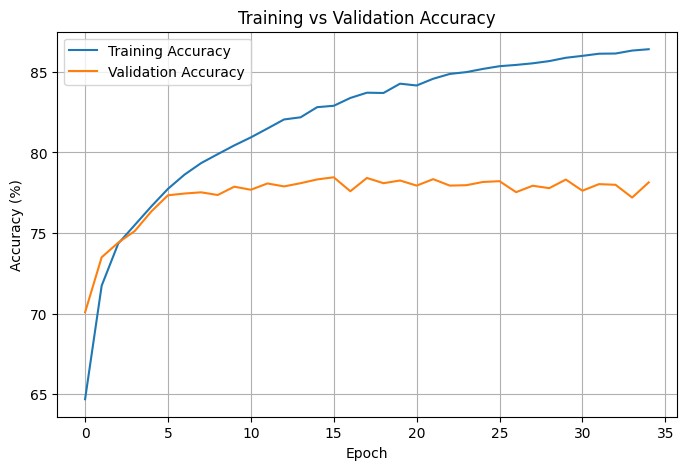

In [90]:
plt.figure(figsize=(8,5))
plt.plot(train_acc, label="Training Accuracy")
plt.plot(val_acc, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy (%)")
plt.title("Training vs Validation Accuracy")
plt.legend()
plt.grid(True)
plt.show()

### Part B: The Tower (Depth Focus) Train a deep but narrow network.

In [91]:
# ==========================================
# 4. YOUR IMPLEMENTATION HERE
# ==========================================


class The_Tower(nn.Module):
    def __init__(self, input_size = 784 , num_classes = 15):
        super(The_Tower,self).__init__()

        self.model = nn.Sequential(
        nn.Flatten(),
        
        nn.Linear(input_size, 250),
        nn.BatchNorm1d(250),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(250, 250),
        nn.BatchNorm1d(250),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(250, 250),
        nn.BatchNorm1d(250),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(250, 250),
        nn.BatchNorm1d(250),
        nn.ReLU(),
        nn.Dropout(0.4),

        nn.Linear(250, 250),
        nn.BatchNorm1d(250),
        nn.ReLU(),
        nn.Dropout(0.4),

       


        nn.Linear(250, num_classes)
        )

    def forward(self, x):
        return self.model(x)





In [92]:
model = The_Tower().to(DEVICE)

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005, weight_decay=5e-4)

Epoch [1/35] | Train Acc: 40.85% | Val Acc: 62.53%
Epoch [2/35] | Train Acc: 59.16% | Val Acc: 66.81%
Epoch [3/35] | Train Acc: 62.78% | Val Acc: 69.51%
Epoch [4/35] | Train Acc: 65.08% | Val Acc: 69.74%
Epoch [5/35] | Train Acc: 66.45% | Val Acc: 71.28%
Epoch [6/35] | Train Acc: 67.36% | Val Acc: 71.70%
Epoch [7/35] | Train Acc: 68.31% | Val Acc: 72.12%
Epoch [8/35] | Train Acc: 69.37% | Val Acc: 72.84%
Epoch [9/35] | Train Acc: 69.95% | Val Acc: 73.34%
Epoch [10/35] | Train Acc: 70.66% | Val Acc: 74.13%
Epoch [11/35] | Train Acc: 71.05% | Val Acc: 74.11%
Epoch [12/35] | Train Acc: 71.71% | Val Acc: 74.32%
Epoch [13/35] | Train Acc: 72.04% | Val Acc: 74.93%
Epoch [14/35] | Train Acc: 72.60% | Val Acc: 75.03%
Epoch [15/35] | Train Acc: 72.81% | Val Acc: 75.28%
Epoch [16/35] | Train Acc: 73.21% | Val Acc: 75.41%
Epoch [17/35] | Train Acc: 73.84% | Val Acc: 75.93%
Epoch [18/35] | Train Acc: 74.21% | Val Acc: 76.08%
Epoch [19/35] | Train Acc: 74.47% | Val Acc: 76.45%
Epoch [20/35] | Train

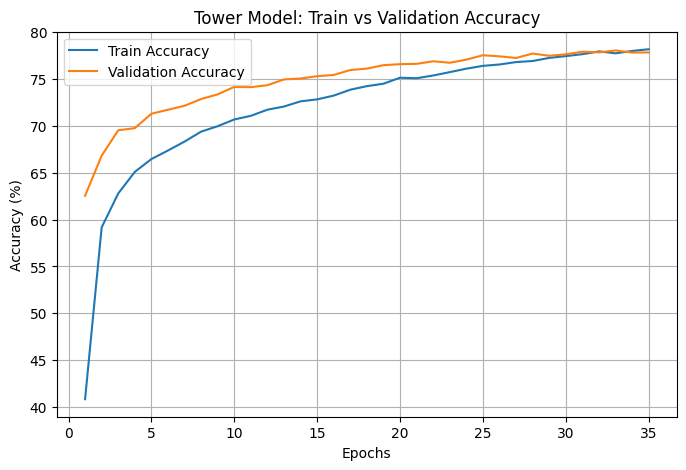

In [93]:
# ------------------------------
# 4. Training Function
# ------------------------------
def train_tower(model, train_loader, val_loader, epochs=35):
    train_acc_list = []
    val_acc_list = []

    for epoch in range(epochs):
        model.train()
        train_correct = 0
        train_total = 0

        for images, labels in train_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        train_accuracy = 100 * train_correct / train_total
        train_acc_list.append(train_accuracy)

        # Validation
        model.eval()
        val_correct = 0
        val_total = 0

        with torch.no_grad():
            for images, labels in val_loader:
                images = images.to(DEVICE)
                labels = labels.to(DEVICE)

                outputs = model(images)
                _, predicted = torch.max(outputs, 1)

                val_total += labels.size(0)
                val_correct += (predicted == labels).sum().item()

        val_accuracy = 100 * val_correct / val_total
        val_acc_list.append(val_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}] | Train Acc: {train_accuracy:.2f}% | Val Acc: {val_accuracy:.2f}%")

    # Plot train vs val accuracy
    plt.figure(figsize=(8,5))
    plt.plot(range(1, epochs+1), train_acc_list, label="Train Accuracy")
    plt.plot(range(1, epochs+1), val_acc_list, label="Validation Accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy (%)")
    plt.title("Tower Model: Train vs Validation Accuracy")
    plt.legend()
    plt.grid(True)
    plt.show()

    return train_acc_list, val_acc_list

# ------------------------------
# 5. Run Training
# ------------------------------
train_acc, val_acc = train_tower(model, train_loader, val_loader, epochs=35)

### Part C: The Champion (Leaderboard Submission) 

In [5]:
# ==========================================
# PART C: THE CHAMPION MODEL (Optimized for Efficiency & Generalization)
# ==========================================
class The_Champion(nn.Module):
    def __init__(self, input_size=784, num_classes=15):
        super(The_Champion, self).__init__()
        self.model = nn.Sequential(
            nn.Flatten(),
            
            # Layer 1: Expansion with heavy regularization
            nn.Linear(input_size, 640),
            nn.BatchNorm1d(640),
            nn.GELU(),
            nn.Dropout(0.4), # Increased to fight overfitting
            
            # Layer 2: Transition
            nn.Linear(640, 480),
            nn.BatchNorm1d(480),
            nn.GELU(),
            nn.Dropout(0.35),
            
            # Layer 3: Bottleneck (The Squeeze)
            nn.Linear(480, 256),
            nn.BatchNorm1d(256),
            nn.GELU(),
            nn.Dropout(0.3),
            
            # Layer 4: Feature refinement
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.GELU(),
            
            # Output
            nn.Linear(128, num_classes)
        )

    def forward(self, x):
        return self.model(x)
    
champion_model = The_Champion().to(DEVICE)

In [6]:
# ==========================================
# TRAINING SETUP
# ==========================================
CHAMPION_EPOCHS = 35 # More epochs allowed now to let regularization work
CHAMPION_BATCH_SIZE = 128 # Balanced batch size

train_loader_c = DataLoader(train_dataset, batch_size=CHAMPION_BATCH_SIZE, shuffle=True)
val_loader_c   = DataLoader(val_dataset,   batch_size=CHAMPION_BATCH_SIZE, shuffle=False)

# HIGHER WEIGHT DECAY: This is the primary weapon against overfitting
optimizer_c = optim.AdamW(champion_model.parameters(), lr=1e-3, weight_decay=0.08)

scheduler = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_c,
    max_lr=2e-3, # Lower peak LR to prevent 'shattering' gradients
    steps_per_epoch=len(train_loader_c),
    epochs=CHAMPION_EPOCHS,
    pct_start=0.3, # 30% warmup
    anneal_strategy='cos',
    final_div_factor=1e5 # Drop LR almost to zero at the end
)

# Label Smoothing is CRITICAL here
criterion_c = nn.CrossEntropyLoss(label_smoothing=0.15)

In [8]:
# ==========================================
# TRAINING LOOP (with Mixup & Gradient Clipping)
# ==========================================
def train_champion(model, train_loader, val_loader, optimizer, scheduler, criterion, epochs):
    train_acc_list, val_acc_list = [], []
    best_val_acc = 0.0
    best_state = None

    for epoch in range(epochs):
        model.train()
        train_correct, train_total = 0, 0
        
        for images, labels in train_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            optimizer.zero_grad()

            # MILD MIXUP (Acts as a regularizer, not data modification)
            lam = np.random.beta(0.1, 0.1)
            idx = torch.randperm(images.size(0))
            mixed_images = lam * images + (1 - lam) * images[idx]
            
            outputs = model(mixed_images)
            loss = lam * criterion(outputs, labels) + (1 - lam) * criterion(outputs, labels[idx])
            
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            scheduler.step()

            _, predicted = torch.max(outputs, 1)
            train_total += labels.size(0)
            train_correct += (predicted == labels).sum().item()

        # Validation
        model.eval()
        val_correct, val_total = 0, 0
        with torch.no_grad():
            for v_images, v_labels in val_loader:
                v_images, v_labels = v_images.to(DEVICE), v_labels.to(DEVICE)
                v_outputs = model(v_images)
                _, v_predicted = torch.max(v_outputs, 1)
                val_total += v_labels.size(0)
                val_correct += (v_predicted == v_labels).sum().item()

        val_acc = 100 * val_correct / val_total
        val_acc_list.append(val_acc)
        train_acc_list.append(100 * train_correct / train_total)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = {k: v.clone() for k, v in model.state_dict().items()}

        print(f"Epoch {epoch+1:02d} | Train: {train_acc_list[-1]:.2f}% | Val: {val_acc:.2f}%")

    model.load_state_dict(best_state)
    return train_acc_list, val_acc_list



# Execute the training
champion_train_acc, champion_val_acc = train_champion(
    champion_model, 
    train_loader_c, 
    val_loader_c, 
    optimizer_c, 
    scheduler, 
    criterion_c, 
    epochs=CHAMPION_EPOCHS
)

Epoch 01 | Train: 25.30% | Val: 64.35%
Epoch 02 | Train: 34.49% | Val: 70.47%
Epoch 03 | Train: 35.29% | Val: 72.35%
Epoch 04 | Train: 37.19% | Val: 73.80%
Epoch 05 | Train: 40.39% | Val: 73.96%
Epoch 06 | Train: 41.47% | Val: 76.34%
Epoch 07 | Train: 40.42% | Val: 77.25%
Epoch 08 | Train: 42.88% | Val: 77.39%
Epoch 09 | Train: 42.23% | Val: 77.53%
Epoch 10 | Train: 40.53% | Val: 77.39%
Epoch 11 | Train: 39.62% | Val: 78.36%
Epoch 12 | Train: 40.66% | Val: 78.57%
Epoch 13 | Train: 40.20% | Val: 79.47%
Epoch 14 | Train: 44.38% | Val: 78.99%
Epoch 15 | Train: 40.78% | Val: 79.05%
Epoch 16 | Train: 50.69% | Val: 79.28%
Epoch 17 | Train: 47.23% | Val: 79.01%
Epoch 18 | Train: 43.90% | Val: 79.82%
Epoch 19 | Train: 46.24% | Val: 79.85%
Epoch 20 | Train: 47.51% | Val: 79.37%
Epoch 21 | Train: 47.07% | Val: 79.72%
Epoch 22 | Train: 44.36% | Val: 79.88%
Epoch 23 | Train: 45.86% | Val: 80.26%
Epoch 24 | Train: 46.84% | Val: 80.28%
Epoch 25 | Train: 48.10% | Val: 80.13%
Epoch 26 | Train: 49.68% 

In [10]:
# Save champion model weights
torch.save(champion_model.state_dict(), 'champion_weights.pth')
print('Champion model weights saved to champion_weights.pth')


Champion model weights saved to champion_weights.pth


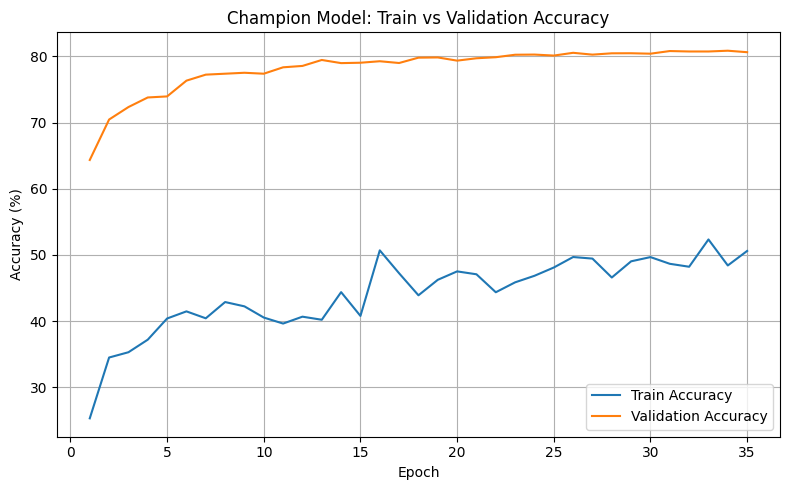

In [11]:
# ==========================================
# CHAMPION: TRAIN vs VAL ACCURACY PLOT
# ==========================================

plt.figure(figsize=(8, 5))
plt.plot(range(1, CHAMPION_EPOCHS + 1), champion_train_acc, label='Train Accuracy')
plt.plot(range(1, CHAMPION_EPOCHS + 1), champion_val_acc,   label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy (%)')
plt.title('Champion Model: Train vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('champion_accuracy.png', dpi=150)
plt.show()


Validation Accuracy (Champion): 80.87%


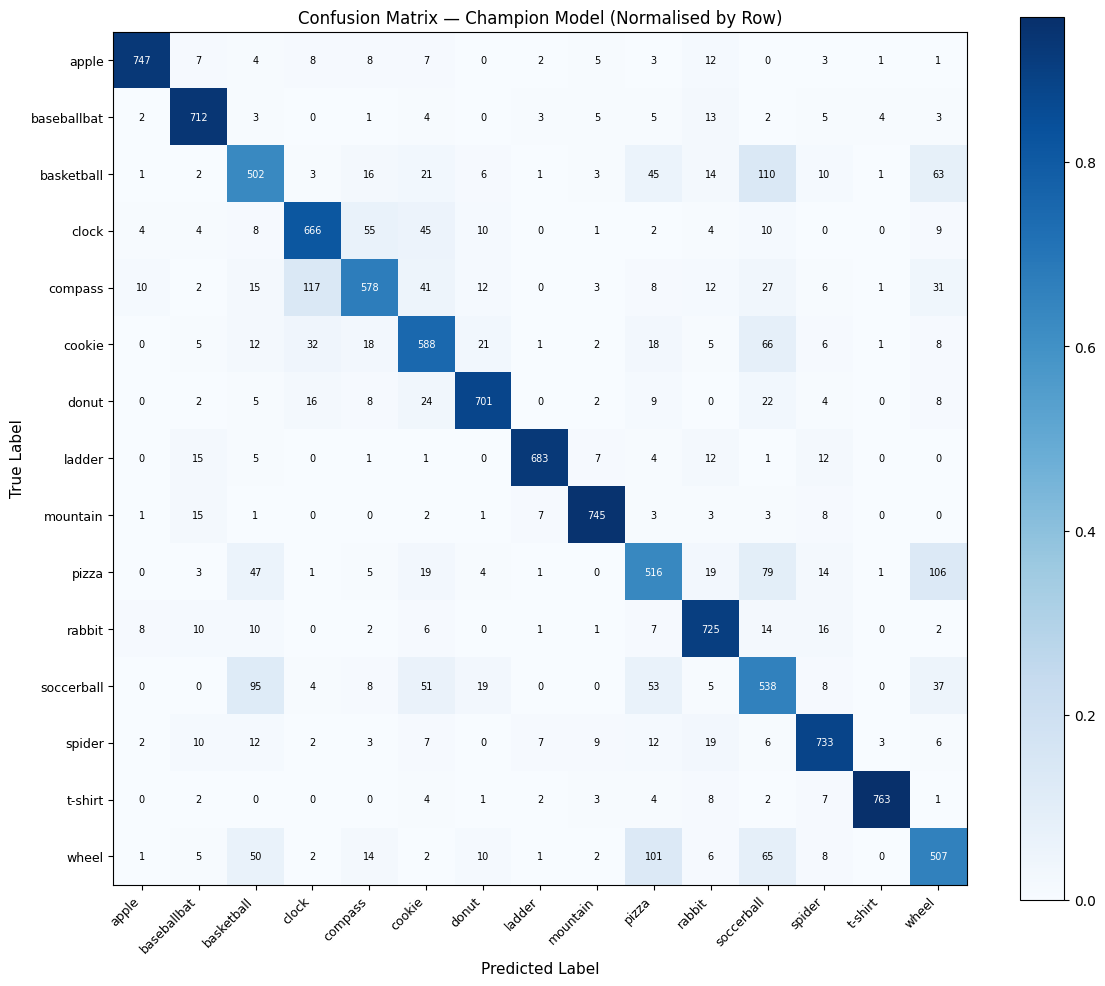

In [12]:
# ==========================================
# PART D: CONFUSION MATRIX (Champion Model)
# ==========================================

def compute_confusion_matrix(model, loader, num_classes=15):
    """Compute confusion matrix without sklearn."""
    model.eval()
    all_preds  = []
    all_labels = []

    with torch.no_grad():
        for images, labels in loader:
            images = images.to(DEVICE)
            outputs = model(images)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.numpy())

    # Build confusion matrix using numpy
    all_preds  = np.array(all_preds)
    all_labels = np.array(all_labels)

    cm = np.zeros((num_classes, num_classes), dtype=int)
    for true, pred in zip(all_labels, all_preds):
        cm[true][pred] += 1

    val_accuracy = 100.0 * (all_preds == all_labels).sum() / len(all_labels)
    print(f"Validation Accuracy (Champion): {val_accuracy:.2f}%")

    return cm


cm = compute_confusion_matrix(champion_model, val_loader_c, num_classes=15)


def plot_confusion_matrix(cm, class_names):
    """Plot confusion matrix as a heatmap using matplotlib only."""
    fig, ax = plt.subplots(figsize=(12, 10))

    # Normalize row-wise so each row sums to 1 (shows recall per class)
    cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

    im = ax.imshow(cm_norm, interpolation='nearest', cmap=plt.cm.Blues)
    plt.colorbar(im, ax=ax)

    ax.set_xticks(range(len(class_names)))
    ax.set_yticks(range(len(class_names)))
    ax.set_xticklabels(class_names, rotation=45, ha='right', fontsize=9)
    ax.set_yticklabels(class_names, fontsize=9)

    # Annotate cells with raw counts
    thresh = cm_norm.max() / 2.0
    for i in range(len(class_names)):
        for j in range(len(class_names)):
            ax.text(j, i, cm[i, j],
                    ha='center', va='center', fontsize=7,
                    color='white' if cm_norm[i, j] > thresh else 'black')

    ax.set_ylabel('True Label', fontsize=11)
    ax.set_xlabel('Predicted Label', fontsize=11)
    ax.set_title('Confusion Matrix — Champion Model (Normalised by Row)', fontsize=12)
    plt.tight_layout()
    plt.savefig('confusion_matrix.png', dpi=150)
    plt.show()


plot_confusion_matrix(cm, CLASSES)


In [13]:
# ==========================================
# TOP CONFUSED CLASS PAIRS
# ==========================================

def top_confused_pairs(cm, class_names, top_n=5):
    """Find the top-N most confused (off-diagonal) class pairs."""
    pairs = []
    n = len(class_names)
    for i in range(n):
        for j in range(n):
            if i != j:
                pairs.append((cm[i, j], class_names[i], class_names[j]))
    pairs.sort(key=lambda x: x[0], reverse=True)

    print(f"Top {top_n} Most Confused Pairs (True -> Predicted):")
    print("-" * 45)
    for count, true_cls, pred_cls in pairs[:top_n]:
        print(f"  {true_cls:>15s}  ->  {pred_cls:<15s}: {count} samples")


top_confused_pairs(cm, CLASSES, top_n=5)


Top 5 Most Confused Pairs (True -> Predicted):
---------------------------------------------
          compass  ->  clock          : 117 samples
       basketball  ->  soccerball     : 110 samples
            pizza  ->  wheel          : 106 samples
            wheel  ->  pizza          : 101 samples
       soccerball  ->  basketball     : 95 samples


In [190]:
import pandas as pd
from sklearn.metrics import accuracy_score

# ==========================================
# 5. INFERENCE & LEADERBOARD VERIFICATION
# ==========================================
print("\n" + "="*40)
print("   GENERATING SUBMISSION FILE")
print("="*40)
# 1. Load Test Images
test_dataset = QuickDrawDataset(TEST_FILE, mode='test')
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

def get_predictions(model, loader):
    model.eval()
    model.to(DEVICE)
    preds = []
    with torch.no_grad():
        for batch in loader:
            X = batch.to(DEVICE)
            outputs = model(X)
            _, predicted = torch.max(outputs, 1)
            preds.extend(predicted.cpu().numpy())
    return preds

# 2. Run Inference
print("Running inference on test set...")
predictions = get_predictions(model, test_loader)

# 3. Save as Comma-Separated Text File
submission_file = "submission.txt"
print(f"Saving predictions to '{submission_file}'...")

# Convert list of ints to comma-separated string (e.g., "0,4,9,2...")
submission_string = ",".join(map(str, predictions))

with open(submission_file, "w") as f:
    f.write(submission_string)
print(f"-> Copy & paste the results of this file to the portal.")


   GENERATING SUBMISSION FILE
Loading test data from ./processed_data/quickdraw_test.npz...
Loaded 15000 test images.
Running inference on test set...
Saving predictions to 'submission.txt'...
-> Copy & paste the results of this file to the portal.


In [9]:
def print_model_size(champion_model):
    total_params = sum(p.numel() for p in champion_model.parameters() if p.requires_grad)
    print(f"\nModel Statistics:")
    print(f"  Total Parameters: {total_params:,}")
    if total_params > 3000000:
        print("  ⚠️ WARNING: You are over the 3M parameter limit!")
    else:
        print("  ✅ Parameter count is within limits.")

print_model_size(champion_model)


Model Statistics:
  Total Parameters: 971,055
  ✅ Parameter count is within limits.
